In [3]:
# generate aquaplanet set up for default testing 
# fixed ssts 
# no land (i.e. no soil, snow, ice vars)
# fmask is 0 everywhere (i.e. water everywhere)

import xarray as xr
import pandas as pd
import numpy as np

save_dir = 'jcm/data/bc/t30/default/'

In [4]:
# open a default speedy data set to get the right values for lat/lon/time
data_ex = xr.open_dataset('~/Documents/Development/speedy.f90/data/bc/t30/clim/snow.nc')
print(data_ex)

<xarray.Dataset> Size: 222kB
Dimensions:  (time: 12, lat: 48, lon: 96)
Coordinates:
  * time     (time) datetime64[ns] 96B 1981-01-01 1981-02-01 ... 1981-12-01
  * lat      (lat) float64 384B 87.16 83.48 79.78 76.07 ... -79.78 -83.48 -87.16
  * lon      (lon) float64 768B 0.0 3.75 7.5 11.25 ... 345.0 348.8 352.5 356.2
    lev      float64 8B ...
Data variables:
    snowd    (time, lat, lon) float32 221kB ...
Attributes:
    CDI:          Climate Data Interface version 1.7.1 (http://mpimet.mpg.de/...
    CDO:          Climate Data Operators version 1.7.1 (http://mpimet.mpg.de/...
    grid_type:    gaussian
    history:      Sun Apr 21 21:23:14 2019: cdo -f nc import_binary snowd.ctl...
    Conventions:  CF-1.5


In [5]:
data_ex = xr.open_dataset('jcm/data/bc/t30/clim/snow.nc')
print(data_ex)
lat = len(data_ex.lat)
lon = len(data_ex.lon)
months = len(data_ex.time)


<xarray.Dataset> Size: 222kB
Dimensions:  (time: 12, lat: 48, lon: 96)
Coordinates:
  * time     (time) datetime64[ns] 96B 1981-01-01 1981-02-01 ... 1981-12-01
  * lat      (lat) float64 384B 87.16 83.48 79.78 76.07 ... -79.78 -83.48 -87.16
  * lon      (lon) float64 768B 0.0 3.75 7.5 11.25 ... 345.0 348.8 352.5 356.2
    lev      float64 8B ...
Data variables:
    snowd    (time, lat, lon) float32 221kB ...
Attributes:
    CDI:          Climate Data Interface version 1.7.1 (http://mpimet.mpg.de/...
    CDO:          Climate Data Operators version 1.7.1 (http://mpimet.mpg.de/...
    grid_type:    gaussian
    history:      Sun Apr 21 21:23:14 2019: cdo -f nc import_binary snowd.ctl...
    Conventions:  CF-1.5


In [6]:
# land (stl) (12 x 48 x 96)
# sea_ice (icec) (12 x 48 x 96)
# snow (snowd) (12 x 48 x 96)
# sea_surface_temperature (sst) (12 x 48 x 96)
# soil, (swl1, swl2, swl3) (all 12 x 48 x 96)
# surface (orog, lsm, vegh, alb, vegl) (all 48 x 96)

# the following can all be zeros because there is no land (ice, snow, soil, or vegetation)
stl = xr.DataArray(np.zeros((months,lat,lon)), 
                   dims=['time','lat','lon'],
                   coords={'time':data_ex.time.values,
                           'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='stl',
                    )
icec = xr.DataArray(np.zeros((months,lat,lon)), 
                   dims=['time','lat','lon'],
                   coords={'time':data_ex.time.values,
                           'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='icec',
                    )
snowd = xr.DataArray(np.zeros((months,lat,lon)), 
                   dims=['time','lat','lon'],
                   coords={'time':data_ex.time.values,
                           'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='snowd',
                    )

# soil
swl1 = xr.DataArray(np.zeros((months,lat,lon)), 
                   dims=['time','lat','lon'],
                   coords={'time':data_ex.time.values,
                           'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='swl1',
                    )
swl2 = xr.DataArray(np.zeros((months,lat,lon)), 
                   dims=['time','lat','lon'],
                   coords={'time':data_ex.time.values,
                           'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='swl2',
                    )
swl3 = xr.DataArray(np.zeros((months,lat,lon)), 
                   dims=['time','lat','lon'],
                   coords={'time':data_ex.time.values,
                           'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='swl3',
                    )

# orography is flat everywhere 
orog = xr.DataArray(np.zeros((lat,lon)), 
                   dims=['lat','lon'],
                   coords={'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='orog',
                    )
vegh = xr.DataArray(np.zeros((lat,lon)), 
                   dims=['lat','lon'],
                   coords={'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='vegh',
                    )
vegl = xr.DataArray(np.zeros((lat,lon)), 
                   dims=['lat','lon'],
                   coords={'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='vegl',
                    )

# all zerosfor all ocean 
lsm = xr.DataArray(np.zeros((lat,lon)), 
                   dims=['lat','lon'],
                   coords={'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='lsm',
                    )
alb = xr.DataArray(np.zeros((lat,lon)), 
                   dims=['lat','lon'],
                   coords={'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='alb',
                    )

In [13]:
import jax.numpy as jnp
radang = data_ex.lat.values * np.pi / 180
sst_profile = jnp.where(jnp.abs(radang) < jnp.pi/3, 27*jnp.cos(3*radang/2)**2, 0) + 273.15
fixed_ssts = jnp.tile(sst_profile[:,jnp.newaxis], (1,lon))

# fixed ssts, copied from boundaries.py:_fixed_ssts
sst = xr.DataArray(np.ones((months,lat,lon))*fixed_ssts[jnp.newaxis,:,:], 
                   dims=['time','lat','lon'],
                   coords={'time':data_ex.time.values,
                           'lat':data_ex.lat.values,
                           'lon':data_ex.lon.values},
                        name='sst',
                    )
# sst = sst*fixed_ssts[jnp.newaxis,:,:]

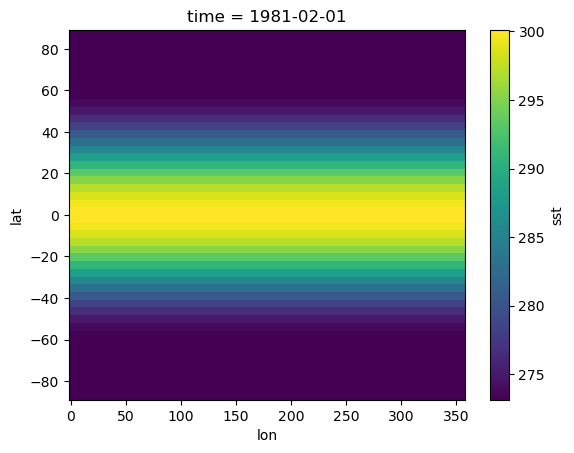

In [14]:
sst[1].plot()

In [15]:
sst.to_netcdf(save_dir + 'sea_surface_temperature.nc')
stl.to_netcdf(save_dir + 'land.nc')
icec.to_netcdf(save_dir + 'sea_ice.nc')
snowd.to_netcdf(save_dir + 'snow.nc')

soil_dataset = xr.Dataset({'swl1':swl1, 'swl2':swl2, 'swl3':swl3})
soil_dataset.to_netcdf(save_dir + 'soil.nc')
surface_dataset = xr.Dataset({'orog':orog, 'lsm':lsm, 'vegh':vegh, 'vegl':vegl, 'alb':alb})
surface_dataset.to_netcdf(save_dir + 'surface.nc')

In [16]:
sst_anom = xr.DataArray(np.zeros((months,lat,lon)), 
                dims=['time','lat','lon'],
                coords={'time':data_ex.time.values,
                        'lat':data_ex.lat.values,
                        'lon':data_ex.lon.values},
                        name='ssta'
                )
sst_anom.to_netcdf(save_dir + 'sea_surface_temperature_anomaly.nc')